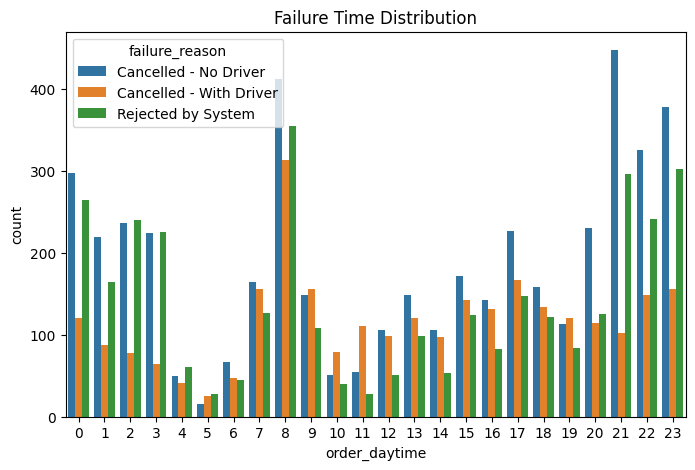

'Overall pattern:\nThere are two clear demand peaks — morning (hour 8) and late evening (hours 21-23) — which follow typical urban transportation patterns. The quietest hours are early morning (hours 4-6), which makes sense.'

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders = pd.read_csv('data_orders.csv')
offers = pd.read_csv('data_offers.csv')

conditions = [
    (orders['order_status_key'] == 4) & (orders['is_driver_assigned_key'] == 0),
    (orders['order_status_key'] == 4) & (orders['is_driver_assigned_key'] == 1),
    (orders['order_status_key'] == 9)
]

labels = [
    'Cancelled - No Driver',
    'Cancelled - With Driver',
    'Rejected by System'
]

orders['order_datetime'] = pd.to_datetime(
    orders['order_datetime'],
    format='%H:%M:%S',
    errors='coerce'
)
orders['failure_reason'] = np.select(conditions, labels, default='Other')
orders['order_daytime'] = orders['order_datetime'].dt.hour

failure_time_distribution = orders.groupby(
    ['order_daytime', 'failure_reason']
).size().reset_index(name='count')

plt.figure(figsize=(8,5))
sns.barplot(data=failure_time_distribution, x='order_daytime', y='count', hue='failure_reason')
plt.title("Failure Time Distribution")
plt.show()
failure_time_distribution = orders.groupby(['order_daytime', 'failure_reason']).size().reset_index(name='count')



Overall pattern:
There are two clear demand peaks — morning (hour 8) and late evening (hours 21-23) — which follow typical urban transportation patterns. The quietest hours are early morning (hours 4-6), which makes sense.